In [ ]:
# 1. SETUP AMBIENTE E LIBRERIE

!pip install timm grad-cam

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import timm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import os
from google.colab import drive


drive.mount('/content/drive')
SAVE_PATH = '/content/drive/MyDrive/Progetto_Denoising_AI/'
os.makedirs(SAVE_PATH, exist_ok=True)

# Configurazione Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=e0feff72011fd956449d1668f61535146e7bf2f68cae7329abe27f914dc0d0c2
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
Mounted at /content/drive


In [ ]:
# 2. DATASET E TRASFORMAZIONI MODULARI (CORRETTO)

import torch
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms

# --- Classi di Rumore ---
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=1.):
        self.std = std
        self.mean = mean

    def __call__(self, tensor):
        return torch.clamp(tensor + torch.randn(tensor.size()) * self.std + self.mean, 0., 1.)

class AddSaltPepperNoise(object):
    def __init__(self, prob=0.1):
        self.prob = prob

    def __call__(self, tensor):

        noise_tensor = tensor.clone()
        rnd = torch.rand_like(tensor)

        # Se prob=0.1 -> il 5% dei pixel diventa nero, il 5% bianco
        noise_tensor[rnd < self.prob/2] = 0.0      # Pepper
        noise_tensor[rnd > 1 - self.prob/2] = 1.0  # Salt
        return noise_tensor

# --- Dataset Standardizzato (32x32),indipendentemente dal dataset di origine (FashionMNIST, CIFAR10 o CIFAR100), tutte le immagini vengono ridimensionate a 32x32 pixel.---
class DenoisingDataset(Dataset):
    def __init__(self, dataset_name, split='train', noise_transform=None):
        self.noise_transform = noise_transform

        self.base_transform = transforms.Compose([
            transforms.Resize((32, 32)),
            transforms.ToTensor()
        ])

        # Selezione Dataset
        if dataset_name == 'FashionMNIST':
            self.data = torchvision.datasets.FashionMNIST(root='./data', train=(split=='train'), download=True, transform=self.base_transform)
            self.channels = 1 #Canale diverso poichè è bianco e nero
        elif dataset_name == 'CIFAR10':
            self.data = torchvision.datasets.CIFAR10(root='./data', train=(split=='train'), download=True, transform=self.base_transform)
            self.channels = 3
        elif dataset_name == 'CIFAR100':
            self.data = torchvision.datasets.CIFAR100(root='./data', train=(split=='train'), download=True, transform=self.base_transform)
            self.channels = 3


    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        clean_img, _ = self.data[idx]

        if self.noise_transform:
            noisy_img = self.noise_transform(clean_img)
        else:
            noisy_img = clean_img

        return noisy_img, clean_img

def get_dataloaders(dataset_name, batch_size=64):

    noise_strategy = AddGaussianNoise(mean=0., std=0.1)

    train_ds = DenoisingDataset(dataset_name, split='train', noise_transform=noise_strategy)
    val_ds = DenoisingDataset(dataset_name, split='test', noise_transform=noise_strategy)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, train_ds.channels

In [ ]:
#3 --ARCHITETTURA DEI MODELLI (Creazione dei modelli)--

class SimpleAE(nn.Module): #rete poco profonda
    def __init__(self, channels):
        super(SimpleAE, self).__init__()
        # Encoder: Comprime l'immagine
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, 16, 3, stride=2, padding=1), # Dimezza dim
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # Dimezza dim
            nn.ReLU()
        )
        # Decoder: Ricostruisce
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, channels, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid() # Output tra 0 e 1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


class DeepNoSkipAE(nn.Module): #molto più profonda ma sequenziale, questa rete ha un problema, l'informazione deve attraversare un collo di bottiglia molto stretto
    def __init__(self, channels):
        super(DeepNoSkipAE, self).__init__()

        # Encoder Profondo (5 layers)
        layers = []
        in_c = channels
        dims = [32, 64, 128, 256]
        for out_c in dims:
            layers.append(nn.Conv2d(in_c, out_c, 3, stride=2, padding=1))
            layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU())
            in_c = out_c
        self.encoder = nn.Sequential(*layers)

        # Decoder Profondo
        layers_dec = []
        for out_c in reversed(dims[:-1]): # 128, 64, 32
            layers_dec.append(nn.ConvTranspose2d(in_c, out_c, 3, stride=2, padding=1, output_padding=1))
            layers_dec.append(nn.BatchNorm2d(out_c))
            layers_dec.append(nn.ReLU())
            in_c = out_c

        # Ultimo layer per tornare ai canali originali
        layers_dec.append(nn.ConvTranspose2d(32, channels, 3, stride=2, padding=1, output_padding=1))
        layers_dec.append(nn.Sigmoid())
        self.decoder = nn.Sequential(*layers_dec)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# --- MODELLO C: Deep WITH Skip / ResNet Style ---
# Usa connessioni residuali per preservare i dettagli ad alta frequenza.
class ResidualBlock(nn.Module):
    def __init__(self, in_channels):
        super(ResidualBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels, in_channels, 3, padding=1),
            nn.BatchNorm2d(in_channels)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out += residual
        out = self.relu(out)
        return out

class DeepSkipAE(nn.Module):
    def __init__(self, channels):
        super(DeepSkipAE, self).__init__()
        # Encoder iniziale
        self.enc_conv1 = nn.Conv2d(channels, 64, 3, padding=1)
        self.res1 = ResidualBlock(64)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.enc_conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.res2 = ResidualBlock(128)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Decoder (Simmetrico)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec_res1 = ResidualBlock(64)

        self.up2 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.dec_res2 = ResidualBlock(64)

        self.final = nn.Conv2d(64, channels, 3, padding=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        x = self.enc_conv1(x)
        x = self.res1(x) # Blocco residuo
        x = self.pool1(x)

        x = self.enc_conv2(x)
        x = self.res2(x) # Blocco residuo
        x = self.pool2(x)

        # Decoder
        x = self.up1(x)
        x = self.dec_res1(x)

        x = self.up2(x)
        x = self.dec_res2(x)

        x = self.final(x)
        return self.sigmoid(x)

# --- MODELLO D: Transfer Learning con TIMM ---
class TransferLearningAE(nn.Module):
    def __init__(self, channels):
        super(TransferLearningAE, self).__init__()
        # Carichiamo ResNet18 da timm
        # ResNet nasce per 3 canali. Se FashionMNIST ne ha 1, dobbiamo adattare il primo layer.
        self.encoder = timm.create_model('resnet18', pretrained=True, features_only=True)

        # Se i canali non sono 3 (FashionMNIST), forziamo il primo layer
        if channels != 3:
            original_conv = self.encoder.conv1
            self.encoder.conv1 = nn.Conv2d(channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
            # Copiamo i pesi dei canali (media dei 3 canali originali per inizializzare)
            with torch.no_grad():
                self.encoder.conv1.weight[:] = torch.mean(original_conv.weight, dim=1, keepdim=True)

        # L'encoder di ResNet riduce l'immagine di 32x. Dobbiamo ricostruire.

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 2, stride=2), # da 1/32 a 1/16
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 2, stride=2), # da 1/16 a 1/8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 2, stride=2),  # da 1/8 a 1/4
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, stride=2),   # da 1/4 a 1/2
            nn.ReLU(),
            nn.ConvTranspose2d(32, channels, 2, stride=2), # da 1/2 a 1/1
            nn.Sigmoid()
        )

    def forward(self, x):
        # features è una lista di tensori a diverse risoluzioni
        features = self.encoder(x)
        # prendiamo l'ultima feature map (la più compressa)
        latent = features[-1]
        reconstruction = self.decoder(latent)
        return reconstruction


In [ ]:
!pip install torchmetrics

from torchmetrics.functional import structural_similarity_index_measure as ssim
from torchmetrics.functional import peak_signal_noise_ratio as psnr

# 4. TRAINING LOOP E VALUTAZIONE AVANZATA

def evaluate_metrics(model, val_loader):
    """Calcola MSE, PSNR e SSIM sull'intero validation set"""
    model.eval()
    mse_accum = 0.0
    psnr_accum = 0.0
    ssim_accum = 0.0
    criterion = nn.MSELoss()
    total_batches = len(val_loader)

    with torch.no_grad():
        for noisy_imgs, clean_imgs in val_loader:
            noisy_imgs, clean_imgs = noisy_imgs.to(device), clean_imgs.to(device)
            outputs = model(noisy_imgs)

            # MSE(calcola la differenza quadratica media tra i pixel ricostruiti e quelli originali)
            loss = criterion(outputs, clean_imgs)
            mse_accum += loss.item()

            # PSNR(misura la purezza del segnale in decibel)
            psnr_accum += psnr(outputs, clean_imgs, data_range=1.0).item()

            # SSIM(valuta quanto i bordi e le forme degli oggetti siano stati preservati)
            ssim_accum += ssim(outputs, clean_imgs, data_range=1.0).item()

    return mse_accum / total_batches, psnr_accum / total_batches, ssim_accum / total_batches

def train_model(model, train_loader, val_loader, epochs=5, model_name="model", dataset_name="data"):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Storia delle metriche
    history = {'train_loss': [], 'val_mse': [], 'val_psnr': [], 'val_ssim': []}

    print(f"\n--- Training: {model_name} su {dataset_name} ---")

    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss = 0.0
        for noisy_imgs, clean_imgs in train_loader:
            noisy_imgs, clean_imgs = noisy_imgs.to(device), clean_imgs.to(device)

            optimizer.zero_grad()
            outputs = model(noisy_imgs)
            loss = criterion(outputs, clean_imgs)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation Phase
        val_mse, val_psnr, val_ssim = evaluate_metrics(model, val_loader)

        history['train_loss'].append(avg_train_loss)
        history['val_mse'].append(val_mse)
        history['val_psnr'].append(val_psnr)
        history['val_ssim'].append(val_ssim)

        print(f"Epoch [{epoch+1}/{epochs}] | MSE: {val_mse:.4f} | PSNR: {val_psnr:.2f} dB | SSIM: {val_ssim:.4f}")

    # Salvataggio con nome completo
    save_path = f"{SAVE_PATH}{model_name}_{dataset_name}.pth"
    torch.save(model.state_dict(), save_path)
    print(f"Modello salvato: {save_path}")

    return history

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 21.4 MB/s eta 0:00:00


In [ ]:
# 5. GRAD-CAM DINAMICO E UNIVERSALE

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
#Questa classe contribuisce a mostrare quali pixel dell'input hanno contribuito maggiormente a generare pixel dell'output
class SemanticSegmentationTarget:
    """
    Target specifico per task di ricostruzione/segmentazione.
    Invece di cercare una classe specifica, chiediamo a Grad-CAM
    di massimizzare la somma dei pixel attivati nell'output.
    """
    def __init__(self, category):
        self.category = category

    def __call__(self, model_output):
        return (model_output).sum()

def get_target_layer(model, model_name):
    """
    Restituisce il layer target corretto per Grad-CAM in base all'architettura.
    """
    if model_name == 'SimpleAE':
        # Ultimo layer conv dell'encoder
        return model.encoder[2]
    elif model_name == 'DeepNoSkip':
        # Ultimo blocco conv dell'encoder (prima del decoder)
        # DeepNoSkip ha una sequenza lineare, prendiamo l'ultimo Conv2d
        # model.encoder è un Sequential. L'ultimo conv è a indice -3 (conv, batch, relu)
        return model.encoder[-3]
    elif model_name == 'DeepSkip':
        # L'ultimo blocco residuo dell'encoder
        return model.res2.conv[3] # Seconda conv del blocco residuo
    elif model_name == 'TransferResNet':
        # Ultimo layer di ResNet18 (layer4)
        return model.encoder.layer4[-1]
    else:
        raise ValueError(f"Layer target non definito per {model_name}")

def run_gradcam_universal(model, dataset_loader, model_name):
    print(f"--- Analisi Grad-CAM: {model_name} ---")
    model.eval()
    data, _ = next(iter(dataset_loader))
    input_tensor = data[0:1].to(device) # Batch size 1

    # Target layer dinamico
    try:
        target_layer = get_target_layer(model, model_name)
    except Exception as e:
        print(f"Skipping Grad-CAM per {model_name}: {e}")
        return

    # Usiamo il wrapper per la somma delle attivazioni
    targets = [SemanticSegmentationTarget(0)]

    # Istanziamo GradCAM
    use_cuda = True if torch.cuda.is_available() else False

    with GradCAM(model=model, target_layers=[target_layer]) as cam:
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

        # Plotting
        img = data[0].permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min()) # Normalizzazione 0-1

        # Se grayscale, dobbiamo farlo RGB per sovrapporre la mappa termica
        if img.shape[2] == 1:
            img = np.repeat(img, 3, axis=2)

        # Resize della CAM
        if grayscale_cam.shape != img.shape[:2]:
             grayscale_cam = cv2.resize(grayscale_cam, (img.shape[1], img.shape[0]))

        visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

        plt.figure(figsize=(6, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title("Input")

        plt.subplot(1, 2, 2)
        plt.imshow(visualization)
        plt.axis('off')
        plt.title(f"Focus ({model_name})")
        plt.show()
        plt.close()


In [ ]:
#5.5 FUNZIONI DI SUPPORTO VISIVO

def visualize_results(model, loader, model_name):
    """
    Funzione helper per visualizzare: Originale | Rumoroso | Ricostruito
    """
    model.eval()
    noisy_imgs, clean_imgs = next(iter(loader))
    noisy_imgs, clean_imgs = noisy_imgs.to(device), clean_imgs.to(device)

    with torch.no_grad():
        reconstructed = model(noisy_imgs)

    # Portiamo su CPU per plot
    noisy = noisy_imgs.cpu()
    clean = clean_imgs.cpu()
    recon = reconstructed.cpu()

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Risultati: {model_name}")

    # Mostriamo prime 5 immagini
    for i in range(5):
        # Originale
        plt.subplot(3, 5, i+1)
        plt.imshow(clean[i].permute(1, 2, 0).squeeze(), cmap='gray' if clean.shape[1]==1 else None)
        plt.axis('off')
        if i==2: plt.title("Originale")

        # Rumorosa
        plt.subplot(3, 5, i+6)
        plt.imshow(noisy[i].permute(1, 2, 0).squeeze(), cmap='gray' if clean.shape[1]==1 else None)
        plt.axis('off')
        if i==2: plt.title("Input Rumoroso")

        # Ricostruita
        plt.subplot(3, 5, i+11)
        plt.imshow(recon[i].permute(1, 2, 0).squeeze(), cmap='gray' if clean.shape[1]==1 else None)
        plt.axis('off')
        if i==2: plt.title("Denoised (Output)")

    plt.show()
    plt.close() # Chiude la figura per liberare memoria


--- AVVIO PROTOCOLLO PER DATASET: CIFAR10 ---


100%|██████████| 170M/170M [00:03<00:00, 48.6MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]


--- Training: SimpleAE su CIFAR10 ---


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `peak_signal_noise_ratio` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `peak_signal_noise_ratio` from `torchmetrics.image` instead.
  _future_warning(
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch [1/30] | MSE: 0.0051 | PSNR: 22.94 dB | SSIM: 0.7551
Epoch [2/30] | MSE: 0.0038 | PSNR: 24.26 dB | SSIM: 0.7941
Epoch [3/30] | MSE: 0.0031 | PSNR: 25.15 dB | SSIM: 0.8138
Epoch [4/30] | MSE: 0.0028 | PSNR: 25.56 dB | SSIM: 0.8221
Epoch [5/30] | MSE: 0.0028 | PSNR: 25.52 dB | SSIM: 0.8259
Epoch [6/30] | MSE: 0.0026 | PSNR: 25.86 dB | SSIM: 0.8284
Epoch [7/30] | MSE: 0.0025 | PSNR: 26.01 dB | SSIM: 0.8317
Epoch [8/30] | MSE: 0.0024 | PSNR: 26.12 dB | SSIM: 0.8334
Epoch [9/30] | MSE: 0.0024 | PSNR: 26.16 dB | SSIM: 0.8341
Epoch [10/30] | MSE: 0.0024 | PSNR: 26.19 dB | SSIM: 0.8344
Epoch [11/30] | MSE: 0.0024 | PSNR: 26.24 dB | SSIM: 0.8351
Epoch [12/30] | MSE: 0.0023 | PSNR: 26.30 dB | SSIM: 0.8363
Epoch [13/30] | MSE: 0.0023 | PSNR: 26.34 dB | SSIM: 0.8375
Epoch [14/30] | MSE: 0.0023 | PSNR: 26.38 dB | SSIM: 0.8381
Epoch [15/30] | MSE: 0.0023 | PSNR: 26.42 dB | SSIM: 0.8385
Epoch [16/30] | MSE: 0.0023 | PSNR: 26.43 dB | SSIM: 0.8383
Epoch [17/30] | MSE: 0.0023 | PSNR: 26.43 dB | SS

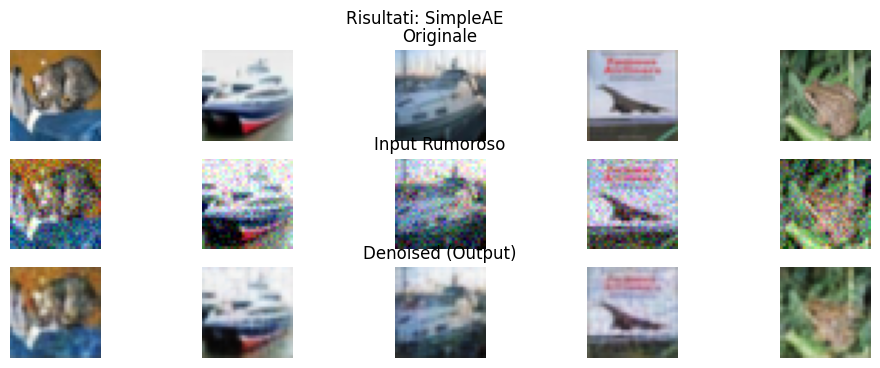

--- Analisi Grad-CAM: SimpleAE ---


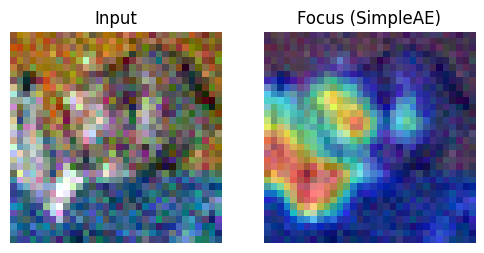


--- Training: DeepNoSkip su CIFAR10 ---
Epoch [1/30] | MSE: 0.0071 | PSNR: 21.51 dB | SSIM: 0.6710
Epoch [2/30] | MSE: 0.0073 | PSNR: 21.38 dB | SSIM: 0.7219
Epoch [3/30] | MSE: 0.0050 | PSNR: 22.98 dB | SSIM: 0.7473
Epoch [4/30] | MSE: 0.0046 | PSNR: 23.39 dB | SSIM: 0.7629
Epoch [5/30] | MSE: 0.0051 | PSNR: 22.89 dB | SSIM: 0.7661
Epoch [6/30] | MSE: 0.0043 | PSNR: 23.64 dB | SSIM: 0.7881
Epoch [7/30] | MSE: 0.0039 | PSNR: 24.09 dB | SSIM: 0.7976
Epoch [8/30] | MSE: 0.0035 | PSNR: 24.53 dB | SSIM: 0.8061
Epoch [9/30] | MSE: 0.0036 | PSNR: 24.49 dB | SSIM: 0.8076
Epoch [10/30] | MSE: 0.0033 | PSNR: 24.85 dB | SSIM: 0.8160
Epoch [11/30] | MSE: 0.0036 | PSNR: 24.44 dB | SSIM: 0.8143
Epoch [12/30] | MSE: 0.0033 | PSNR: 24.83 dB | SSIM: 0.8199
Epoch [13/30] | MSE: 0.0030 | PSNR: 25.19 dB | SSIM: 0.8243
Epoch [14/30] | MSE: 0.0030 | PSNR: 25.27 dB | SSIM: 0.8264
Epoch [15/30] | MSE: 0.0030 | PSNR: 25.17 dB | SSIM: 0.8295
Epoch [16/30] | MSE: 0.0029 | PSNR: 25.34 dB | SSIM: 0.8319
Epoch [1

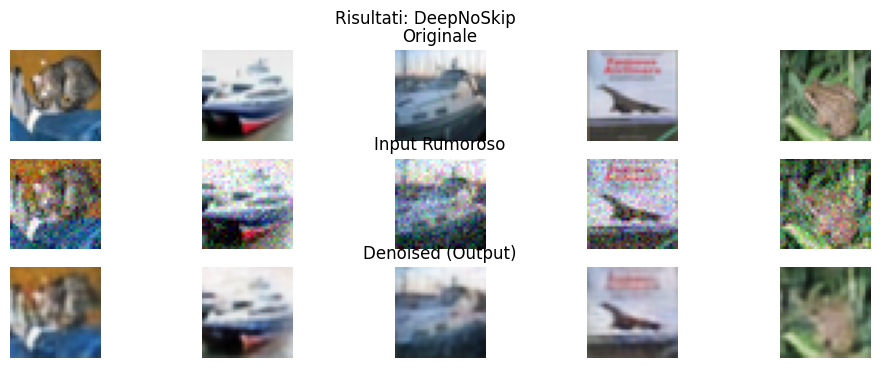

--- Analisi Grad-CAM: DeepNoSkip ---


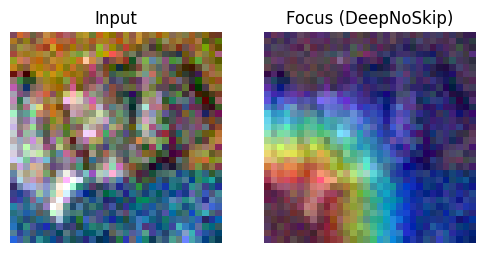


--- Training: DeepSkip su CIFAR10 ---
Epoch [1/30] | MSE: 0.0028 | PSNR: 25.49 dB | SSIM: 0.8391
Epoch [2/30] | MSE: 0.0034 | PSNR: 24.70 dB | SSIM: 0.8445
Epoch [3/30] | MSE: 0.0035 | PSNR: 24.59 dB | SSIM: 0.8528
Epoch [4/30] | MSE: 0.0024 | PSNR: 26.21 dB | SSIM: 0.8640
Epoch [5/30] | MSE: 0.0031 | PSNR: 25.08 dB | SSIM: 0.8585
Epoch [6/30] | MSE: 0.0023 | PSNR: 26.45 dB | SSIM: 0.8705
Epoch [7/30] | MSE: 0.0022 | PSNR: 26.55 dB | SSIM: 0.8743
Epoch [8/30] | MSE: 0.0020 | PSNR: 27.05 dB | SSIM: 0.8801
Epoch [9/30] | MSE: 0.0019 | PSNR: 27.15 dB | SSIM: 0.8811
Epoch [10/30] | MSE: 0.0021 | PSNR: 26.86 dB | SSIM: 0.8843
Epoch [11/30] | MSE: 0.0019 | PSNR: 27.22 dB | SSIM: 0.8833
Epoch [12/30] | MSE: 0.0018 | PSNR: 27.50 dB | SSIM: 0.8833
Epoch [13/30] | MSE: 0.0017 | PSNR: 27.61 dB | SSIM: 0.8846
Epoch [14/30] | MSE: 0.0017 | PSNR: 27.62 dB | SSIM: 0.8882
Epoch [15/30] | MSE: 0.0019 | PSNR: 27.25 dB | SSIM: 0.8878
Epoch [16/30] | MSE: 0.0018 | PSNR: 27.44 dB | SSIM: 0.8839
Epoch [17/

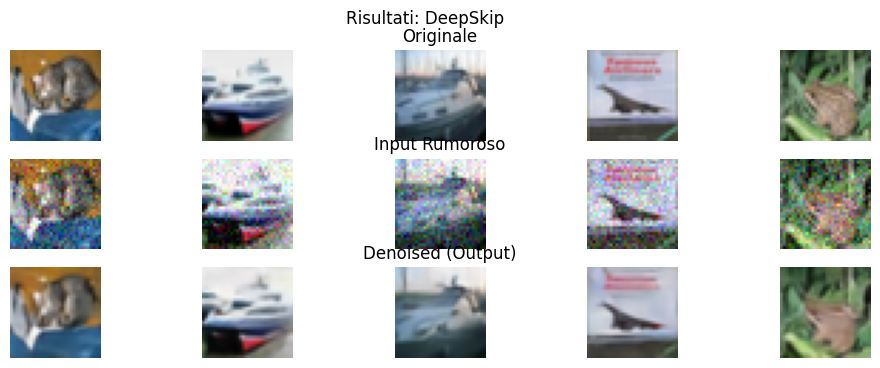

--- Analisi Grad-CAM: DeepSkip ---


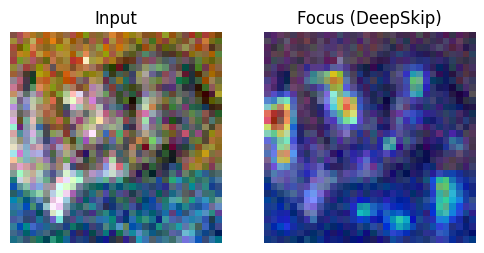


--- Training: TransferResNet su CIFAR10 ---
Epoch [1/30] | MSE: 0.0213 | PSNR: 16.72 dB | SSIM: 0.3300
Epoch [2/30] | MSE: 0.0178 | PSNR: 17.50 dB | SSIM: 0.3838
Epoch [3/30] | MSE: 0.0160 | PSNR: 17.96 dB | SSIM: 0.4222
Epoch [4/30] | MSE: 0.0147 | PSNR: 18.32 dB | SSIM: 0.4482
Epoch [5/30] | MSE: 0.0140 | PSNR: 18.56 dB | SSIM: 0.4725
Epoch [6/30] | MSE: 0.0126 | PSNR: 19.00 dB | SSIM: 0.4941
Epoch [7/30] | MSE: 0.0118 | PSNR: 19.30 dB | SSIM: 0.5141
Epoch [8/30] | MSE: 0.0111 | PSNR: 19.56 dB | SSIM: 0.5294
Epoch [9/30] | MSE: 0.0108 | PSNR: 19.69 dB | SSIM: 0.5347
Epoch [10/30] | MSE: 0.0108 | PSNR: 19.68 dB | SSIM: 0.5478
Epoch [11/30] | MSE: 0.0103 | PSNR: 19.89 dB | SSIM: 0.5584
Epoch [12/30] | MSE: 0.0101 | PSNR: 19.97 dB | SSIM: 0.5646
Epoch [13/30] | MSE: 0.0096 | PSNR: 20.19 dB | SSIM: 0.5755
Epoch [14/30] | MSE: 0.0093 | PSNR: 20.32 dB | SSIM: 0.5825
Epoch [15/30] | MSE: 0.0092 | PSNR: 20.38 dB | SSIM: 0.5920
Epoch [16/30] | MSE: 0.0099 | PSNR: 20.04 dB | SSIM: 0.5886
Epoc

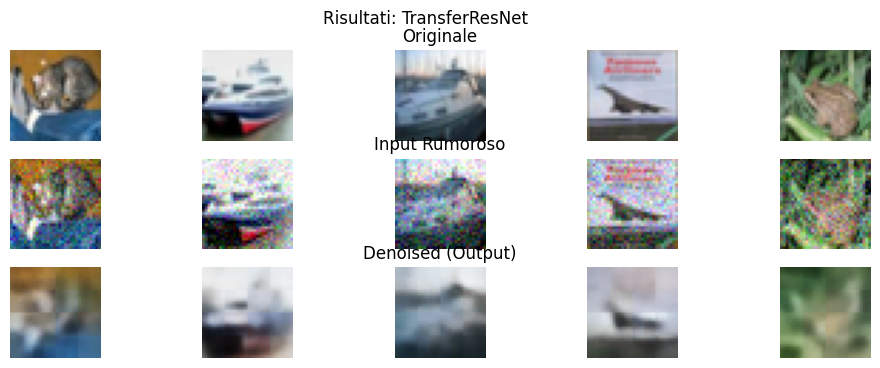

--- Analisi Grad-CAM: TransferResNet ---


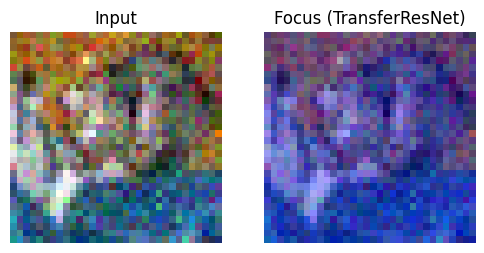


--- CONFRONTO FINALE (CIFAR10) ---
Modello         | MSE (Low is better)  | PSNR (High is better) | SSIM (High is better)
--------------------------------------------------------------------------------
SimpleAE        | 0.00219              | 26.59 dB             | 0.8403
DeepNoSkip      | 0.00257              | 25.90 dB             | 0.8457
DeepSkip        | 0.00164              | 27.87 dB             | 0.8936
TransferResNet  | 0.00750              | 21.26 dB             | 0.6443


In [ ]:
# --- CONFIGURAZIONE ESECUZIONE ---
CURRENT_DATASET = 'CIFAR10'
EPOCHS = 30

print(f"--- AVVIO PROTOCOLLO PER DATASET: {CURRENT_DATASET} ---")

# 1. Carica Dati
train_loader, val_loader, channels = get_dataloaders(CURRENT_DATASET)

# 2. Istanzia Modelli
models_dict = {
    'SimpleAE': SimpleAE(channels),
    'DeepNoSkip': DeepNoSkipAE(channels),
    'DeepSkip': DeepSkipAE(channels),
    'TransferResNet': TransferLearningAE(channels)
}

results = {}

# 3. Training Loop Comparativo
for name, model in models_dict.items():
    try:
        # Chiamata con dataset_name
        history = train_model(model, train_loader, val_loader, epochs=EPOCHS, model_name=name, dataset_name=CURRENT_DATASET)

        # Visualizzazione
        visualize_results(model, val_loader, name)

        # Salviamo le metriche finali per il confronto stampato
        results[name] = {
            'MSE': history['val_mse'][-1],
            'PSNR': history['val_psnr'][-1],
            'SSIM': history['val_ssim'][-1]
        }

        # 4. Grad-CAM Universale
        run_gradcam_universal(model, val_loader, name)

    except Exception as e:
        print(f"ERRORE CRITICO su {name}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n--- CONFRONTO FINALE ({CURRENT_DATASET}) ---")
print(f"{'Modello':<15} | {'MSE (Low is better)':<20} | {'PSNR (High is better)':<20} | {'SSIM (High is better)':<20}")
print("-" * 80)
for name, metrics in results.items():
    print(f"{name:<15} | {metrics['MSE']:.5f}              | {metrics['PSNR']:.2f} dB             | {metrics['SSIM']:.4f}")
